### Import standard libraries & Set up plotting styles

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import pandas_ta_classic as ta
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from nsepy import get_history
from datetime import date


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12# Set random seeds for reproducibility
np.random.seed(42)

### Data Extraction & Preprocessing

In [3]:
def download_stock_data(ticker, start_date, end_date):
    try:
        df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust=True)
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error downloading data for {ticker}: {e}")
        return pd.DataFrame()

### Visualize the preprocessed data 

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

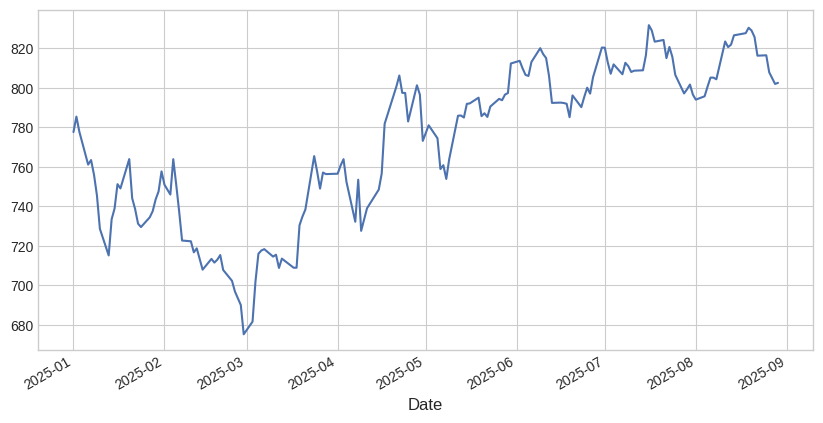

In [22]:
ticker = ["SBIN.NS"]
start_date = '2025-01-01'
end_date = '2025-09-01'
df = download_stock_data(ticker, start_date, end_date)
ma_period = 10
vma_period = 7
capital = 100000 # Total amount to be invested
df["Close"].plot()

### Create Functions to calculate Technical Indicators

In [23]:
def calculate_rsi(data, period=14):
    delta = data.diff()
    
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    ema_fast = data.ewm(span=fast).mean()
    ema_slow = data.ewm(span=slow).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal).mean()
    histogram = macd_line - signal_line
    
    return macd_line, signal_line, histogram

def calculate_sma(data, period=ma_period):
    return data.rolling(window=period).mean()

def calculate_ema(data, period=ma_period):
    return data.ewm(span=period).mean()

def calculate_volume_sma(volume, period=vma_period):
    return volume.rolling(window=period).mean()
    

### Feature Engineering & Feature Selection
- Create Features 
- Select the most relevant features to train the model

In [24]:
def create_features(df):
    df_indicators = df.copy()
    
    # Calculate daily returns
    df_indicators['returns'] = df_indicators['Close'].pct_change()
    
    # Calculate n-period Simple Moving Average (SMA)
    df_indicators['sma'] = df_indicators['Close'].rolling(window=ma_period).mean()

    # Add RSI and MACD indicators
    df_indicators["rsi"] = calculate_rsi(df_indicators["Close"])
    macd_line, signal_line, histogram = calculate_macd(df_indicators['Close'])
    df_indicators['macd'] = macd_line
    df_indicators['macd_signal'] = signal_line
    df_indicators['macd_histogram'] = histogram

    # Add SMA and volume average indicators
    df_indicators['sma_10'] = calculate_sma(df_indicators['Close'])
    df_indicators['sma_50'] = calculate_sma(df_indicators['Close'], period=50)
    df_indicators['sma_200'] = calculate_sma(df_indicators['Close'], period=200)
    df_indicators['ema'] = calculate_ema(df_indicators['Close'])
    df_indicators['volume_sma'] = calculate_volume_sma(df_indicators['Volume'])


    
    # Handle infinite values and NaNs created by transformations
    df_indicators = df_indicators.replace([np.inf, -np.inf], np.nan)
    df_indicators = df_indicators.ffill().bfill()

    # # Fix potential MultiIndex columns
    # if isinstance(df_indicators.columns, pd.MultiIndex):
    #     df_indicators.columns = df_indicators.columns.get_level_values(0)
    # return df_indicators

    
    return df_indicators

df_indicators = create_features(df)

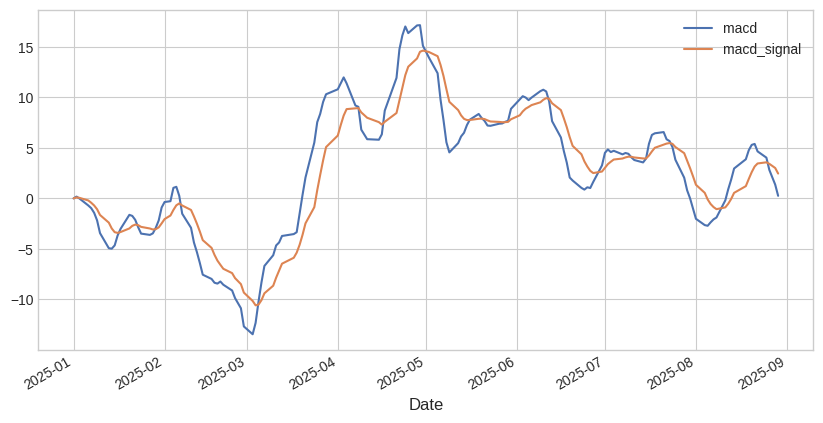

<Axes: xlabel='Date'>

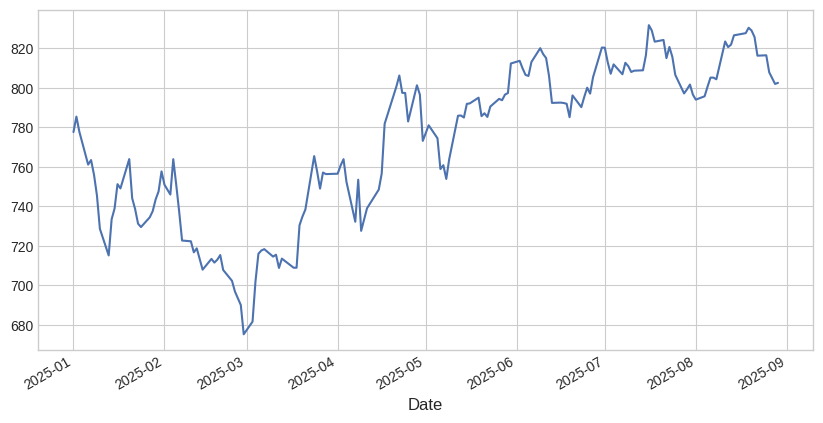

In [25]:
df_indicators["macd"].plot()
df_indicators["macd_signal"].plot()
# df_indicators["macd_histogram"].plot()
# df_indicators["rsi"].plot()
# plt.axhline(y=30)
# plt.axhline(y=70)
# plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-04-30"))
plt.legend()
plt.show()

df_indicators["Close"].plot()
# plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-04-30"))

### Devise The Trading startegy / Generate Signals for long / short / flat calls
- Suggested by **Parth Parmar** on 03.11.2025
- Combines multiple technical indicators to generate **buy**, **sell**, or **flat** signals.  
- Uses volume, momentum (RSI), trend (SMA crossover), and MACD-based confirmations to decide positions.


#### **Conditions**

- **C1 (Volume Confirmation):**  
  Daily trading volume crosses above its 7-day simple moving average (SMA).  
  → Participation only when market activity is high.

- **C2 (RSI Momentum):**  
  RSI crosses above 30 but remains below 70.  
  → Filters out oversold (<30) and overbought (>70) regimes.

- **C3 (Trend Confirmation):**  
  A *Golden Cross* occurs — 50-day SMA crosses above the 200-day SMA.  
  → Indicates a transition to a long-term bullish trend.

- **C4 (MACD Confirmation):**  
  MACD line crosses above the signal line.  
  → Confirms short-term bullish momentum from MACD dynamics.

---

#### **Trading Rules**

- **Trade only when C1 (volume condition) is satisfied.**

| Signal Type | Conditions Met |
|--------------|----------------|
| **Buy (1)**  | C1 **and** at least two of (C2–C4) are satisfied |
| **Sell (-1)**| C1 **and** none of (C2–C4) are satisfied |
| **Flat (0)** | C1 not satisfied **or** exactly one of (C2–C4) is satisfied **or** RSI < 30 |

---

Each day, the strategy evaluates these conditions to determine the position:
- `1` → **Go Long (Buy)**
- `-1` → **Go Short (Sell)**
- `0` → **Stay Flat**


In [26]:
def generate_trading_signals(df_indicators):
    # Calculate conditions
    df_indicators['C1'] = df_indicators['Volume'] > df_indicators['volume_sma']
    df_indicators['C2'] = (df_indicators['rsi'] > 30) & (df_indicators['rsi'] < 70)
    df_indicators['C3'] = df_indicators['sma_50'] > df_indicators['sma_200']
    df_indicators['C4'] = df_indicators['macd'] > df_indicators['macd_signal']
    
    # Calculate additional conditions for sell signals
    df_indicators['rsi_overbought'] = df_indicators['rsi'] > 70
    df_indicators['death_cross'] = df_indicators['sma_50'] < df_indicators['sma_200']
    df_indicators['macd_bearish'] = df_indicators['macd'] < df_indicators['macd_signal']
    
    # Count satisfied conditions C2-C4
    df_indicators['conditions_count'] = df_indicators['C2'].astype(int) + df_indicators['C3'].astype(int) + df_indicators['C4'].astype(int)
    
    # Generate signals
    df_indicators['signal'] = 0  # Default to flat
    
    # Buy signal: C1 satisfied AND at least 2 of C2-C4 satisfied AND RSI not oversold
    buy_condition = (
        df_indicators['C1'] & 
        (df_indicators['conditions_count'] >= 2) &
        (df_indicators['rsi'] >= 30)  # RSI not below 30
    )
    df_indicators.loc[buy_condition, 'signal'] = 1
    
    # Sell signal: C1 satisfied AND (no other conditions satisfied OR bearish conditions)
    sell_condition = (
        df_indicators['C1'] & 
        (
            (df_indicators['conditions_count'] == 0) |
            (df_indicators['rsi_overbought'] & df_indicators['death_cross'] & df_indicators['macd_bearish'])
        )
    )
    df_indicators.loc[sell_condition, 'signal'] = -1
    
    # Ensure flat when C1 not satisfied OR only one condition satisfied OR RSI < 30
    flat_condition = (
        ~df_indicators['C1'] |
        (df_indicators['conditions_count'] == 1) |
        (df_indicators['rsi'] < 30)
    )
    df_indicators.loc[flat_condition, 'signal'] = 0

    return df_indicators

df_signals = generate_trading_signals(df_indicators)

In [27]:
# df_signals["C1"]
print("C1 signal:", df_signals.C1.value_counts())
print("C2 Signal:", df_signals.C2.value_counts())
print("C3 Signal", df_signals.C3.value_counts())
print("C4 Signal:", df_signals.C4.value_counts())

C1 signal: C1
False    101
True      64
Name: count, dtype: int64
C2 Signal: C2
True     135
False     30
Name: count, dtype: int64
C3 Signal C3
False    165
Name: count, dtype: int64
C4 Signal: C4
True     83
False    82
Name: count, dtype: int64


### Simulate Positions
- Simulate positions based on the strategy devised above

In [28]:
def simulate_positions(df_signals):
    df = df_signals.copy()

    # Shift signal by 1 day to avoid lookahead bias (trade next day)
    df['position'] = df['signal'].shift(1).fillna(0)

    # Strategy daily returns
    df['strategy_returns'] = df['position'] * df['returns']

    return df

df_positions = simulate_positions(df_signals)

### Backtesting the strategy
- Option to include or ignore transaction fees
- Calculate the performance Metrics

In [33]:
def run_backtest(df, initial_capital=capital):
    df = df.copy()

    # Ensure required columns exist
    if 'returns' not in df.columns or 'strategy_returns' not in df.columns:
        raise ValueError("DataFrame must contain 'returns' and 'strategy_returns' columns.")

    # Cumulative returns (percentage)
    df['cum_market'] = (1 + df['returns']).cumprod() - 1
    df['cum_strategy'] = (1 + df['strategy_returns']).cumprod() - 1

    # Capital Movement
    df["capital_equity"] = initial_capital * (1 + df['cum_strategy'])
    final_equity = df["capital_equity"].iloc[-1]
    total_return_pct = (final_equity - initial_capital) / initial_capital * 100

    # Annualized Sharpe ratio (assume 252 trading days)
    daily_mean = df['strategy_returns'].mean()
    daily_std  = df['strategy_returns'].std()
    sharpe = (np.sqrt(252) * daily_mean / daily_std) if daily_std != 0 else np.nan

    # Maximum drawdown on strategy equity curve
    equity = (1 + df['strategy_returns']).cumprod()
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_drawdown = drawdown.min()  # negative number

    metrics = {
        "Cumulative Strategy Return (%)": round(df['cum_strategy'].iloc[-1] * 100, 4),
        "Cumulative Market Return (%)": round(df['cum_market'].iloc[-1] * 100, 4),
        "Annualized Sharpe Ratio": round(sharpe, 4),
        "Maximum Drawdown (%)": round(max_drawdown * 100, 4),
        'Final Equity (₹)': final_equity,
        'Initial Capital (₹)': initial_capital,

    }
    
    return metrics, df

metrics, df_backtest = run_backtest(df_positions)

metrics

{'Cumulative Strategy Return (%)': -3.7398,
 'Cumulative Market Return (%)': 4.2448,
 'Annualized Sharpe Ratio': -0.6618,
 'Maximum Drawdown (%)': -5.522,
 'Final Equity (₹)': 96260.20227913295,
 'Initial Capital (₹)': 100000}

### Plot the Equity Curve (PnL Curve)

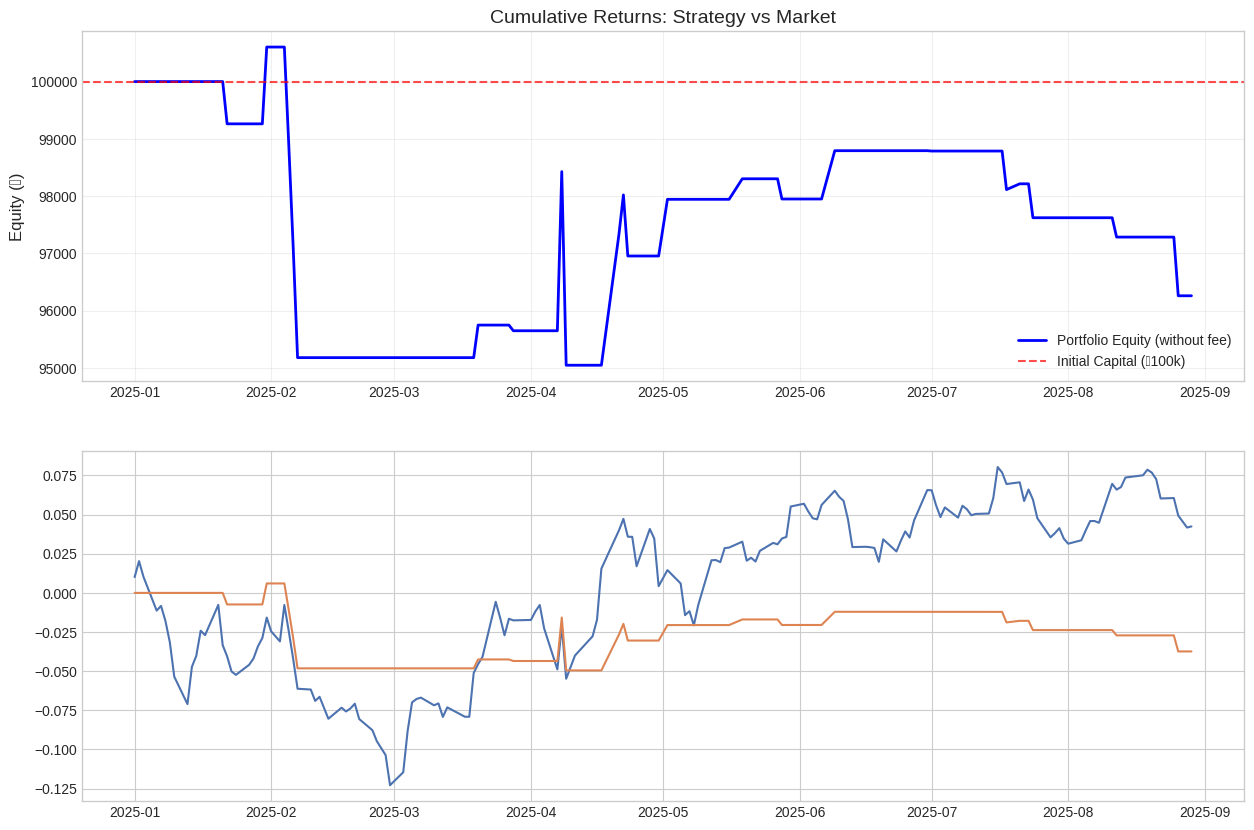

In [36]:
def plot_backtest_results(df_backtest):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Equity curve
    ax1.plot(df_backtest.index, df_backtest['capital_equity'], linewidth=2, color='blue', label='Portfolio Equity (without fee)')
    # ax1.plot(df_backtest_with_fee.index, df_backtest_with_fee['equity'], linewidth=2, color='orange', label='Portfolio Equity (with fee)')
    ax1.axhline(y=100000, color='red', linestyle='--', alpha=0.7, label='Initial Capital (₹100k)')
    ax1.set_title('Portfolio Equity Curve')
    ax1.set_ylabel('Equity (₹)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Drawdown
    ax2.plot(df_backtest.index, df_backtest['cum_market'], label='Market (buy & hold)')
    ax2.plot(df_backtest.index, df_backtest['cum_strategy'], label='Strategy')
    ax1.set_title('Cumulative Returns: Strategy vs Market')
    
    # plt.tight_layout()
    # plt.savefig("equity_curve.pdf", format="pdf", dpi=300)
    # plt.show()
plot_backtest_results(df_backtest)

### Backup Code

In [23]:
def run_backtest(df_positions, initial_capital=capital, transaction_cost=0.0002):

    df_backtest = df_positions.copy()

    # Base period returns from positions
    df_backtest['period_return'] = df_backtest['position'].shift(1) * df_backtest['returns']

    # Identify trades (when position changes)
    df_backtest['trade_flag'] = df_backtest['position'].diff().abs()

    # Apply transaction costs (only on trade events)
    # Each position change (enter, exit, or flip) costs "transaction_cost"
    df_backtest['cost'] = df_backtest['trade_flag'] * transaction_cost

    # Subtract cost from period return (assumes cost is proportional to capital)
    df_backtest['net_return'] = df_backtest['period_return'] - df_backtest['cost']

    # Compute cumulative equity and drawdown
    df_backtest['cumulative_return'] = (1 + df_backtest['net_return'].fillna(0)).cumprod()
    df_backtest['equity'] = initial_capital * df_backtest['cumulative_return']
    df_backtest['equity_peak'] = df_backtest['equity'].cummax()
    df_backtest['drawdown'] = (df_backtest['equity_peak'] - df_backtest['equity']) / df_backtest['equity_peak']

    return df_backtest

df_backtest = run_backtest(df_positions)
# df_backtest_with_fee = run_backtest(df_positions, transaction_cost = 0.0002)

def calculate_performance_metrics(df_backtest, initial_capital=capital):
    # Remove rows with NaN (first few periods without returns)
    df_valid = df_backtest.dropna(subset=['period_return'])
    
    if len(df_valid) == 0:
        print(" No valid data for performance calculation")
        return {}
    
    # Total return
    final_equity = df_valid['equity'].iloc[-1]
    total_return_pct = (final_equity - initial_capital) / initial_capital * 100
    
    # Number of trades (count position changes, excluding the initial position)
    position_changes = (df_valid['position'] != df_valid['position'].shift(1)).sum()
    num_trades = max(0, position_changes - 1)  # Subtract initial position setting
    
    # Maximum drawdown
    max_drawdown_pct = df_valid['drawdown'].max() * 100
    
    # Sharpe Ratio    
    annualization_factor = np.sqrt(252)
    return_col = 'net_return' if 'net_return' in df_valid.columns else 'period_return'
    excess_returns = df_valid[return_col]  # Use cost-adjusted returns if available
    sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * annualization_factor
    
    metrics = {
        'Total Return (%)': total_return_pct,
        'Number of Trades': num_trades,
        'Maximum Drawdown (%)': max_drawdown_pct,
        'Sharpe Ratio': sharpe_ratio,
        'Final Equity (₹)': final_equity,
        'Initial Capital (₹)': initial_capital
    }
    
    return metrics

metrics = calculate_performance_metrics(df_backtest)
# metrics_with_fee = calculate_performance_metrics(df_backtest_with_fee)

print("The performance metrics without transaction fees:", metrics, "\n")
# print("The performance metrics with transaction fees:", metrics_with_fee, "\n")

In [ ]:
def generate_trading_signals(df_indicators):
    df = df_indicators.copy()

    # Condition C1: Volume crosses above its 7-day SMA
    df['C1'] = (df['Volume'] > df['volume_sma'])

    # Condition C2: RSI between 30 and 70, and crossing above 30
    df['C2'] = ((df['rsi'] > 30) & (df['rsi'] < 70) & (df['rsi'].shift(1) <= 30))

    # Condition C3: Golden crossover (50-SMA crosses above 200-SMA)
    df['C3'] = ((df['sma_50'] > df['sma_200']) & (df['sma_50'].shift(1) <= df['sma_200'].shift(1)))

    # Condition C4: MACD signal line crossing MACD line from above
    df['C4'] = ((df['macd'] > df['macd_signal']) & (df['macd'].shift(1) <= df['macd_signal'].shift(1)))

    # Generate trading signals
    df['signal'] = 0  # default: flat

    # Only trade when C1 is satisfied
    trade_condition = df['C1']

    # Count how many of C2–C4 are true
    df['num_conditions'] = df[['C2', 'C3', 'C4']].sum(axis=1)

    # Buy signal: C1 true AND at least two of (C2–C4) true
    buy_condition = trade_condition & (df['num_conditions'] >= 2)
    df.loc[buy_condition, 'signal'] = 1

    # Sell signal: C1 true AND none of (C2–C4) true
    sell_condition = trade_condition & (df['num_conditions'] == 0)
    df.loc[sell_condition, 'signal'] = -1

    # Flat signal: C1 false OR (C1 true but only one of C2–C4 true) OR RSI < 30
    flat_condition = ~trade_condition | (df['num_conditions'] == 1) | (df['rsi'] < 30)
    df.loc[flat_condition, 'signal'] = 0

    df['crossover'] = 0  # Track crossover events
    df.loc[buy_condition | sell_condition, 'crossover'] = 1  # 1 if crossover happens, 0 otherwise

    return df

df_signals = generate_trading_signals(df_indicators)